In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src import datasets as ds

DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "report" / "Figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

In [2]:
N = 1000
DATA_SEED = 0
SEEDS = range(1)
TEST_SIZE = 0.3 
GAMMA = 0.1
RHO = 0.1
MU = ds.gaussian_mean(bayes_risk=0.1)

In [3]:
rng = np.random.default_rng(DATA_SEED)
X_sep, y_sep = ds.make_separable(N, GAMMA, rng)
X_gau, y_gau = ds.make_gaussian(N, MU, rng)
data = {"separable": (X_sep, y_sep, ds.eta_separable(X_sep)),
        "label_flip": (X_sep, ds.flip_labels(y_sep, RHO, rng), ds.eta_label_flip(X_sep, RHO)),
        "gaussian": (X_gau, y_gau, ds.eta_gaussian(X_gau, MU))}

split_sep = ds.stratified_splits(y_sep, SEEDS, TEST_SIZE)
splits = {"separable": split_sep, "label_flip": split_sep,
          "gaussian": ds.stratified_splits(y_gau, SEEDS, TEST_SIZE)}

for name, (X, y, eta) in data.items():
    train_idx, test_idx = splits[name]
    np.savez_compressed(DATA_DIR / f"{name}.npz", X=X, y=y, eta=eta, train_idx=train_idx, test_idx=test_idx)

In [4]:
X_sp, y_sp = ds.load_spambase(data_home=DATA_DIR)
train_idx, test_idx = ds.stratified_splits(y_sp, SEEDS, TEST_SIZE)
np.savez_compressed(DATA_DIR / "spambase.npz", X=X_sp, y=y_sp, train_idx=train_idx, test_idx=test_idx)
print(f"{len(y_sp)} unique examples, {X_sp.shape[1]} features")

4210 unique examples, 57 features


In [5]:
rows = []
for name in ["separable", "label_flip", "gaussian", "spambase"]:
    X_tr, y_tr, X_te, y_te, eta_te = ds.load_dataset(name, 0, DATA_DIR)
    rows.append({"dataset": name, "n_train": len(y_tr), "n_test": len(y_te), "d": X_tr.shape[1] - 1,
                 "positive fraction": np.mean(y_tr == 1),
                 "Bayes risk": np.nan if eta_te is None else np.mean(np.minimum(eta_te, 1 - eta_te))})
pd.DataFrame(rows).set_index("dataset").round(4)

,n_train,n_test,d,positive fraction,Bayes risk
dataset,,,,,
separable,700,300,2,0.5000,0.0000
label_flip,700,300,2,0.5086,0.1000
gaussian,700,300,2,0.5000,0.0952
spambase,2947,1263,57,0.3987,NaN


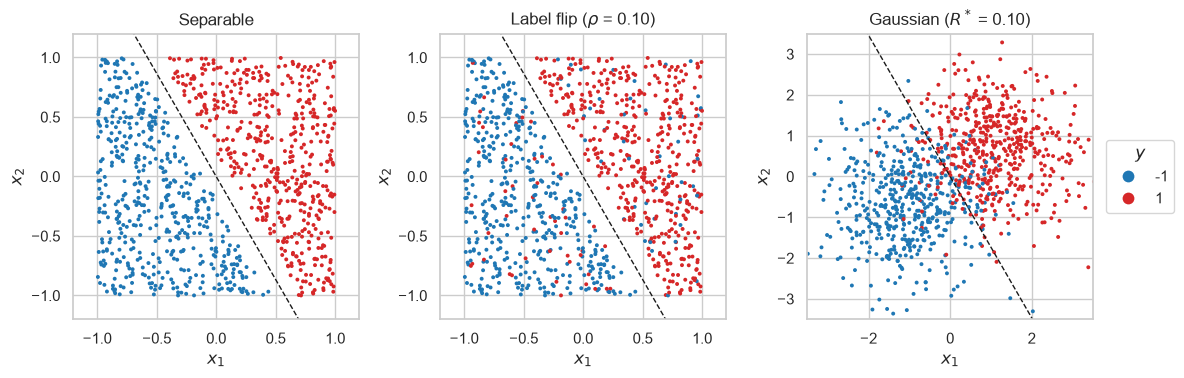

In [8]:
titles = {"separable": "Separable",
          "label_flip": rf"Label flip ($\rho$ = {RHO:.2f})",
          "gaussian": r"Gaussian ($R^*$ = 0.10)"}
boundary = np.outer([-5, 5], [-ds.W_STAR[1], ds.W_STAR[0]])  

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, title) in zip(axes, titles.items()):
    X, y, _ = data[name]
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette={1: "tab:red", -1: "tab:blue"},
                    s=8, linewidth=0, legend=(name == "gaussian"), ax=ax)
    ax.plot(*boundary.T, "k--", lw=1)
    lim = 3.5 if name == "gaussian" else 1.2
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal", title=title, xlabel="$x_1$", ylabel="$x_2$")
sns.move_legend(axes[2], "center left", bbox_to_anchor=(1.02, 0.5), title="$y$", markerscale=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "datasets.pdf", bbox_inches="tight")